Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: sbusisogift
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store


100%|██████████| 4.29G/4.29G [00:45<00:00, 102MB/s] 



Loading data...
Data Loaded. Shape: (681869, 6)
------------------------------
Conversion Analysis:
View-to-Cart: 5.64%
Cart-to-Purchase: 142.86%
Overall Conversion: 8.06%
------------------------------


/tmp/ipykernel_13398/2518464128.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(x=unique_users.index, y=unique_users.values, palette="magma")


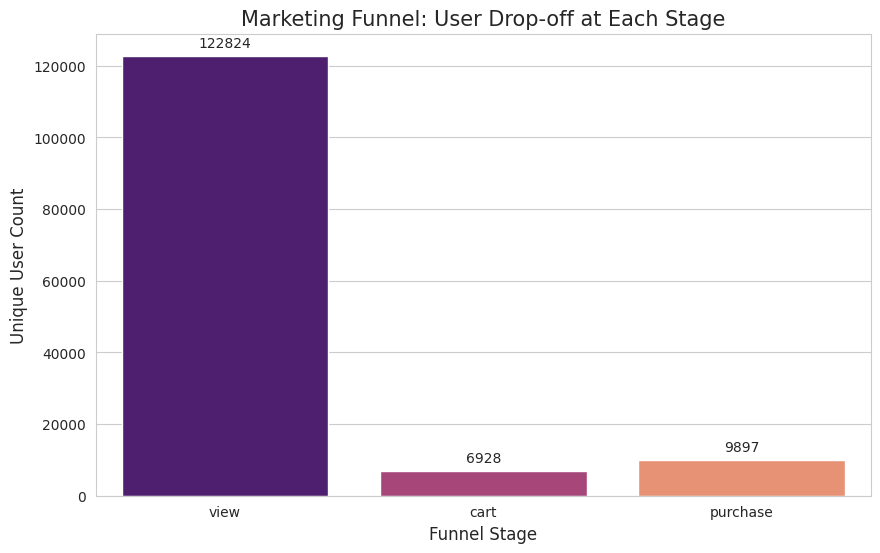

INSIGHT: The biggest leak is at the Interest stage. Focus on improving product descriptions or landing page UX.


In [1]:
# ==========================================
# 1. INSTALL & SETUP
# ==========================================
!pip install opendatasets --quiet

import opendatasets as od
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==========================================
# 2. DOWNLOAD DATASET
# ==========================================
# When you run this, enter your Kaggle Username and Key (from your kaggle.json)
dataset_url = 'https://www.kaggle.com/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store'
od.download(dataset_url)

# ==========================================
# 3. LOAD & CLEAN DATA (Memory Efficient)
# ==========================================
# Path to the October dataset
file_path = './ecommerce-behavior-data-from-multi-category-store/2019-Oct.csv'

# We load only the first 1 million rows to keep it fast for this task.
# We also only load the columns necessary for Funnel Analysis.
cols_to_use = ['event_type', 'user_id', 'user_session', 'category_code', 'brand', 'price']

print("Loading data...")
df = pd.read_csv(file_path, usecols=cols_to_use, nrows=1000000)

# Basic Cleaning
df.dropna(subset=['user_session', 'category_code'], inplace=True)
print(f"Data Loaded. Shape: {df.shape}")

# ==========================================
# 4. FUNNEL ANALYSIS CALCULATION
# ==========================================
# Count unique users at each stage
# The funnel order: view -> cart -> purchase
funnel_stages = ['view', 'cart', 'purchase']
unique_users = df.groupby('event_type')['user_id'].nunique().reindex(funnel_stages)

# Calculate Conversion Rates
# 1. View to Cart
view_to_cart = (unique_users['cart'] / unique_users['view']) * 100
# 2. Cart to Purchase (Critical for identifying 'Abandoned Carts')
cart_to_purchase = (unique_users['purchase'] / unique_users['cart']) * 100
# 3. Total Conversion (View to Purchase)
total_conv = (unique_users['purchase'] / unique_users['view']) * 100

print("-" * 30)
print(f"Conversion Analysis:")
print(f"View-to-Cart: {view_to_cart:.2f}%")
print(f"Cart-to-Purchase: {cart_to_purchase:.2f}%")
print(f"Overall Conversion: {total_conv:.2f}%")
print("-" * 30)

# ==========================================
# 5. VISUALIZATION
# ==========================================
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Create a bar plot representing the funnel
plot = sns.barplot(x=unique_users.index, y=unique_users.values, palette="magma")

# Add labels and title
plt.title('Marketing Funnel: User Drop-off at Each Stage', fontsize=15)
plt.ylabel('Unique User Count', fontsize=12)
plt.xlabel('Funnel Stage', fontsize=12)

# Annotate bars with the actual counts
for p in plot.patches:
    plot.annotate(format(p.get_height(), '.0f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

plt.show()

# ==========================================
# 6. RECOMMENDATION GENERATION (Snippet)
# ==========================================
# Finding the biggest drop-off
drop_off_view_cart = unique_users['view'] - unique_users['cart']
drop_off_cart_purch = unique_users['cart'] - unique_users['purchase']

if drop_off_cart_purch > drop_off_view_cart:
    print("INSIGHT: The biggest leak is at the Checkout stage. Focus on reducing shipping costs or simplifying payment.")
else:
    print("INSIGHT: The biggest leak is at the Interest stage. Focus on improving product descriptions or landing page UX.")

Training the Conversion Prediction Model...

Model Performance Report:
              precision    recall  f1-score   support

           0       0.59      0.84      0.69      3984
           1       0.72      0.40      0.52      3986

    accuracy                           0.62      7970
   macro avg       0.65      0.62      0.61      7970
weighted avg       0.65      0.62      0.61      7970



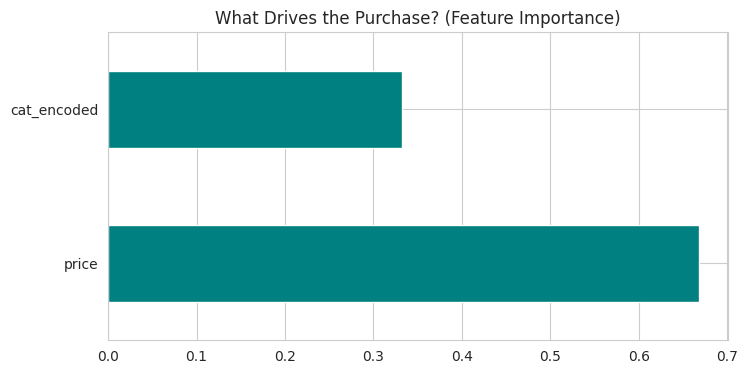

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# 1. Prepare the Data
# We only want to look at users who at least put something in their 'cart'
predict_df = df[df['event_type'].isin(['cart', 'purchase'])].copy()

# Target: Did they actually purchase?
predict_df['target'] = predict_df['event_type'].apply(lambda x: 1 if x == 'purchase' else 0)

# 2. Feature Engineering
# Let's use Price and Category (simplified) as features
le = LabelEncoder()
predict_df['cat_encoded'] = le.fit_transform(predict_df['category_code'].astype(str))

# Create a simplified feature set
X = predict_df[['price', 'cat_encoded']]
y = predict_df['target']

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 4. Model Training
print("Training the Conversion Prediction Model...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Evaluation
y_pred = model.predict(X_test)
print("\nModel Performance Report:")
print(classification_report(y_test, y_pred))

# 6. Feature Importance Visualization
plt.figure(figsize=(8, 4))
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('What Drives the Purchase? (Feature Importance)')
plt.show()